In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
calendar = pd.read_csv("../data/calendar.csv")
sell_prices = pd.read_csv("../data/sell_prices.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")

print("Datasets loaded successfully!")
print("Calendar:", calendar.shape)
print("Sell Prices:", sell_prices.shape)
print("Sales:", sales.shape)

Datasets loaded successfully!
Calendar: (1969, 14)
Sell Prices: (6841121, 4)
Sales: (30490, 1919)


DATASET OVERVIEW
Total Items: 30490
Total Days: 1913
Total Stores: 10
Total States: 3
Total Categories: 3
Date Range: 2011-01-29 to 2016-06-19

Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States: ['CA', 'TX', 'WI']
Categories: ['HOBBIES', 'HOUSEHOLD', 'FOODS']

Total Sales by Category:
cat_id
FOODS        45089939
HOBBIES       6124800
HOUSEHOLD    14480670
Name: total_sales, dtype: int64


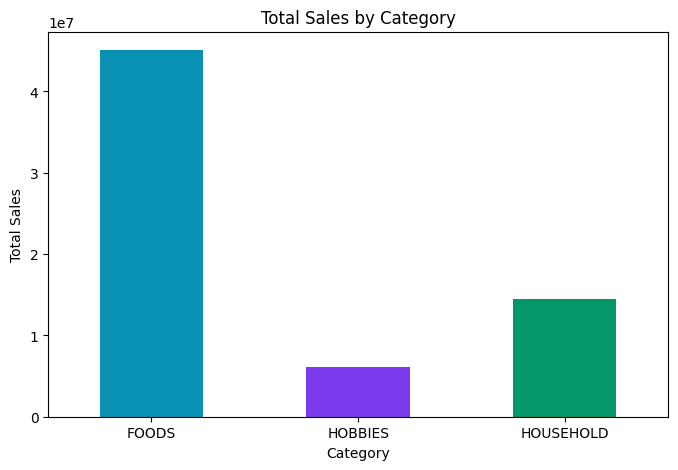

In [2]:
# Basic EDA
sales_cols = [col for col in sales.columns if col.startswith('d_')]

print("DATASET OVERVIEW")
print("="*50)
print("Total Items:", len(sales))
print("Total Days:", len(sales_cols))
print("Total Stores:", sales['store_id'].nunique())
print("Total States:", sales['state_id'].nunique())
print("Total Categories:", sales['cat_id'].nunique())
print("Date Range: 2011-01-29 to 2016-06-19")

print("\nStores:", sales['store_id'].unique().tolist())
print("States:", sales['state_id'].unique().tolist())
print("Categories:", sales['cat_id'].unique().tolist())

# Total sales per category
sales['total_sales'] = sales[sales_cols].sum(axis=1)
print("\nTotal Sales by Category:")
print(sales.groupby('cat_id')['total_sales'].sum())

# Visualize
plt.figure(figsize=(8,5))
sales.groupby('cat_id')['total_sales'].sum().plot(
    kind='bar', color=['#0891B2', '#7C3AED', '#059669'])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

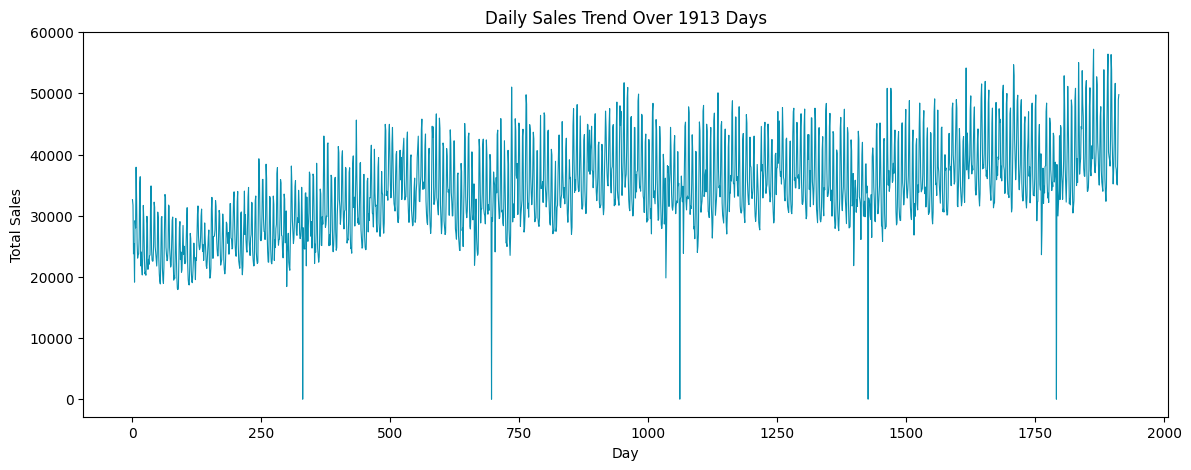

Average Daily Sales: 34341.56
Max Daily Sales: 57218
Min Daily Sales: 11


In [3]:
# Daily Sales Trend
daily_sales = sales[sales_cols].sum(axis=0)
daily_sales.index = range(1, len(daily_sales)+1)

plt.figure(figsize=(14,5))
plt.plot(daily_sales.values, color='#0891B2', linewidth=0.8)
plt.title("Daily Sales Trend Over 1913 Days")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.show()

print("Average Daily Sales:", round(daily_sales.mean(), 2))
print("Max Daily Sales:", daily_sales.max())
print("Min Daily Sales:", daily_sales.min())

Merged Shape: (58327370, 16)


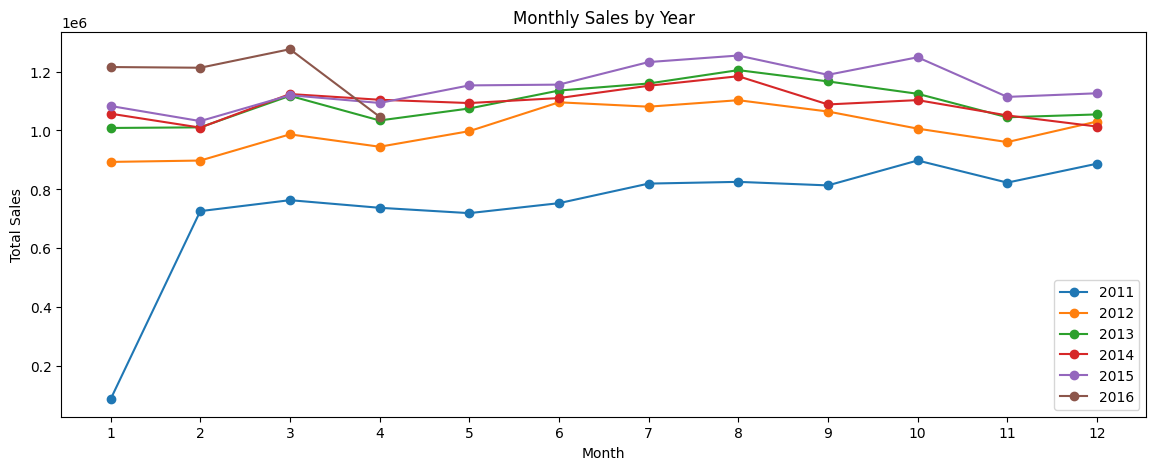

Best Month: 3
Best Year: 2015


In [5]:
# Monthly Analysis
sales_melted = sales[['id', 'item_id', 'cat_id', 'store_id', 'state_id'] + sales_cols].melt(
    id_vars=['id', 'item_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Fix calendar missing values
calendar['event_name_1'] = calendar['event_name_1'].fillna('No Event')
calendar['event_name_2'] = calendar['event_name_2'].fillna('No Event')

# Merge with calendar
sales_melted = sales_melted.merge(
    calendar[['d', 'date', 'month', 'year', 'weekday', 'wday', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']],
    on='d', how='left'
)

print("Merged Shape:", sales_melted.shape)

# Monthly sales
monthly_sales = sales_melted.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(14,5))
for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(data['month'], data['sales'], marker='o', label=str(year))
plt.title("Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(range(1,13))
plt.show()

print("Best Month:", monthly_sales.groupby('month')['sales'].sum().idxmax())
print("Best Year:", monthly_sales.groupby('year')['sales'].sum().idxmax())

In [6]:
# Save summary
print("="*50)
print("EDA SUMMARY REPORT")
print("="*50)
print("Total Items: 30,490")
print("Total Days: 1,913")
print("Total Stores: 10")
print("Total States: 3 (CA, TX, WI)")
print("Total Categories: 3 (FOODS, HOUSEHOLD, HOBBIES)")
print("Average Daily Sales: 34,341")
print("Max Daily Sales: 57,218")
print("Best Month: March")
print("Best Year: 2015")
print("Top Category: FOODS with 45,089,939 sales")
print("Top State: California with 28,675,547 sales")
print("="*50)

EDA SUMMARY REPORT
Total Items: 30,490
Total Days: 1,913
Total Stores: 10
Total States: 3 (CA, TX, WI)
Total Categories: 3 (FOODS, HOUSEHOLD, HOBBIES)
Average Daily Sales: 34,341
Max Daily Sales: 57,218
Best Month: March
Best Year: 2015
Top Category: FOODS with 45,089,939 sales
Top State: California with 28,675,547 sales
